In [1]:
# --- Cell 1: Imports and Model Setup ---

import os
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt

# ChimpUFE: make sure path to src/ is in sys.path
import sys
sys.path.append("../Tracking/ChimpUFE")  # <-- Change to actual ChimpUFE repo root
from src.face_embedder.vision_transformer import vit_base

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# --- Cell 2: Load YOLO Face Detector ---

yolo_face_model = YOLO("./runs/detect/train3/weights/best.pt")  # Adjust path as needed

# For ChimpUFE embedder
def get_chimpufe_model(pretrained_weights, device):
    input_size = 224
    model = vit_base(
        img_size=input_size,
        patch_size=14,
        init_values=1e-05,
        ffn_layer='mlp',
        block_chunks=4,
        qkv_bias=True,
        proj_bias=True,
        ffn_bias=True,
        num_register_tokens=0,
        interpolate_offset=0.1,
        interpolate_antialias=False,
    )
    state_dict = torch.load(pretrained_weights, map_location="cpu", weights_only=False)['teacher']
    state_dict = {k.replace("backbone.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device).eval()
    img_transforms = transforms.Compose([
        transforms.Resize(input_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return model, img_transforms

chimpufe_model, chimpufe_transform = get_chimpufe_model(
    "../Tracking/ChimpUFE/assets/weights/25-08-29T11-49-28_340k.pth", device  # <-- Path to your ChimpUFE weights
)

In [3]:
# --- Cell 3: Set Data Paths ---

chimp_pic_root = "../../ChimpPic/train"   # Folder with subfolders per individual

face_crop_folder = "../../ChimpPic/ChimpPic_face_crops"   # Save face crops here (optional)

os.makedirs(face_crop_folder, exist_ok=True)

In [4]:
# --- Cell 4: Crop Faces from All Images ---

face_db = []  # List to store dicts for each face: {id, crop_path, emb, orig_img_path}
image_db = []

for chimp_id in sorted(os.listdir(chimp_pic_root)):
    chimp_folder = os.path.join(chimp_pic_root, chimp_id)
    if not os.path.isdir(chimp_folder):
        continue
    for imgfile in sorted(os.listdir(chimp_folder)):
        if not imgfile.lower().endswith('.png'):
            continue
        img_path = os.path.join(chimp_folder, imgfile)
        img = Image.open(img_path).convert('RGB')
        img_np = np.array(img)

        # Run YOLO face detection
        yolo_results = yolo_face_model(img_np)[0]
        if len(yolo_results.boxes.xyxy) == 0:
            print(f"No face detected in {img_path}")
            continue

        for i, box in enumerate(yolo_results.boxes.xyxy):
            x1, y1, x2, y2 = [int(b) for b in box.tolist()]
            # Basic square crop with small margin (optional)
            margin = int(0.05 * max(x2 - x1, y2 - y1))
            x1 = max(0, x1 - margin)
            y1 = max(0, y1 - margin)
            x2 = min(img_np.shape[1], x2 + margin)
            y2 = min(img_np.shape[0], y2 + margin)
            face_crop = img_np[y1:y2, x1:x2]
            crop_pil = Image.fromarray(face_crop)

            # Save crop
            crop_name = f"{chimp_id}_{os.path.splitext(imgfile)[0]}_face{i}.png"
            crop_path = os.path.join(face_crop_folder, crop_name)
            crop_pil.save(crop_path)
            face_db.append({'chimp_id': chimp_id, 'crop_path': crop_path, 'orig_img_path': img_path})

        image_db.append(img_path)


0: 384x640 1 Face, 34.9ms
Speed: 14.8ms preprocess, 34.9ms inference, 235.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Face, 4.7ms
Speed: 1.4ms preprocess, 4.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 4.7ms
Speed: 1.4ms preprocess, 4.7ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
No face detected in ../../ChimpPic/train/Amadi/Amadi1_frame_0237.png

0: 384x640 1 Face, 4.6ms
Speed: 1.5ms preprocess, 4.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Face, 4.6ms
Speed: 1.3ms preprocess, 4.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Face, 4.7ms
Speed: 1.4ms preprocess, 4.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 4.6ms
Speed: 1.4ms preprocess, 4.6ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
No face detected in ../../ChimpPic/train/Amadi/Amadi1_

In [5]:
# --- Cell 5: Compute ChimpUFE Embeddings for Each Crop ---

def get_embedding(model, img, device):
    img = chimpufe_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(img)
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)
    return emb.squeeze(0).cpu().numpy()

for entry in tqdm(face_db, desc='ChimpUFE Faces'):
    img = Image.open(entry['crop_path']).convert('RGB')
    entry['embedding'] = get_embedding(chimpufe_model, img, device)

ChimpUFE Faces: 100%|██████████| 21/21 [00:02<00:00, 10.44it/s]


Dropdown(description='Chimpanzee:', options=('Amadi', 'Banalia', 'Binasera', 'Djiku', 'Ivan', 'Jeje', 'Kira'),…

Dropdown(description='Crop Image:', options=('Amadi_Amadi1_frame_0051_face0.png', 'Amadi_Amadi1_frame_0155_fac…

Button(description='Find Top Matches', style=ButtonStyle())

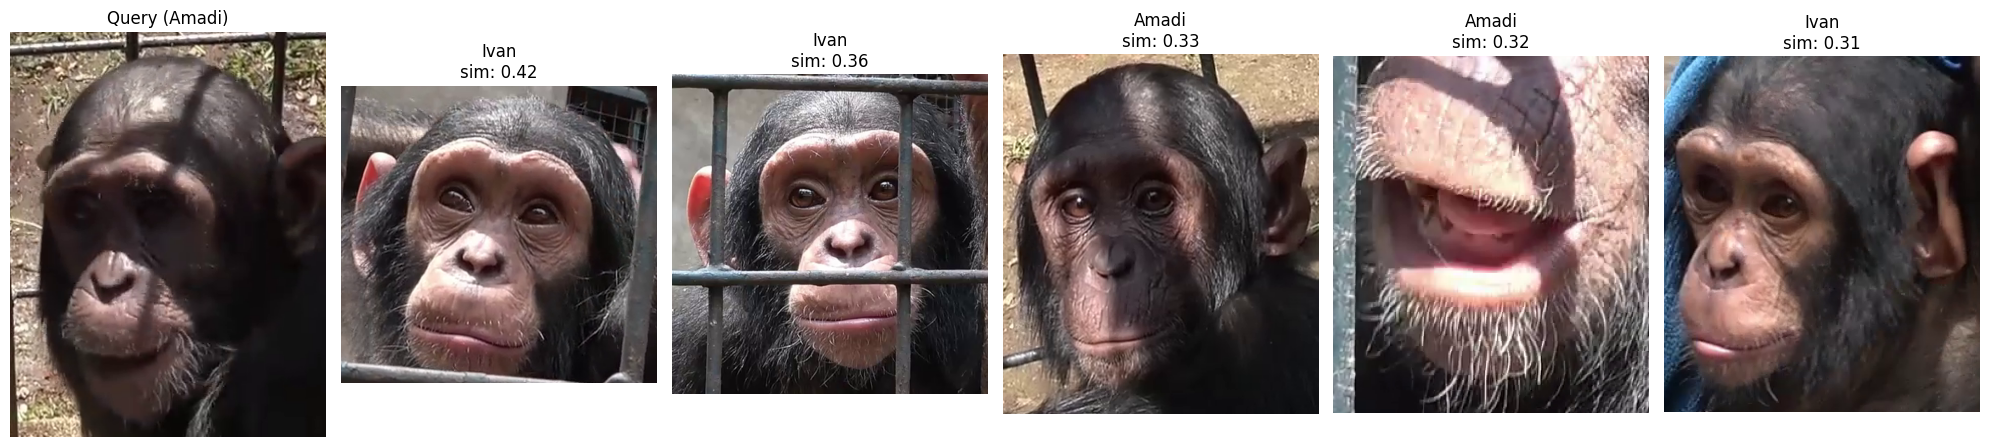

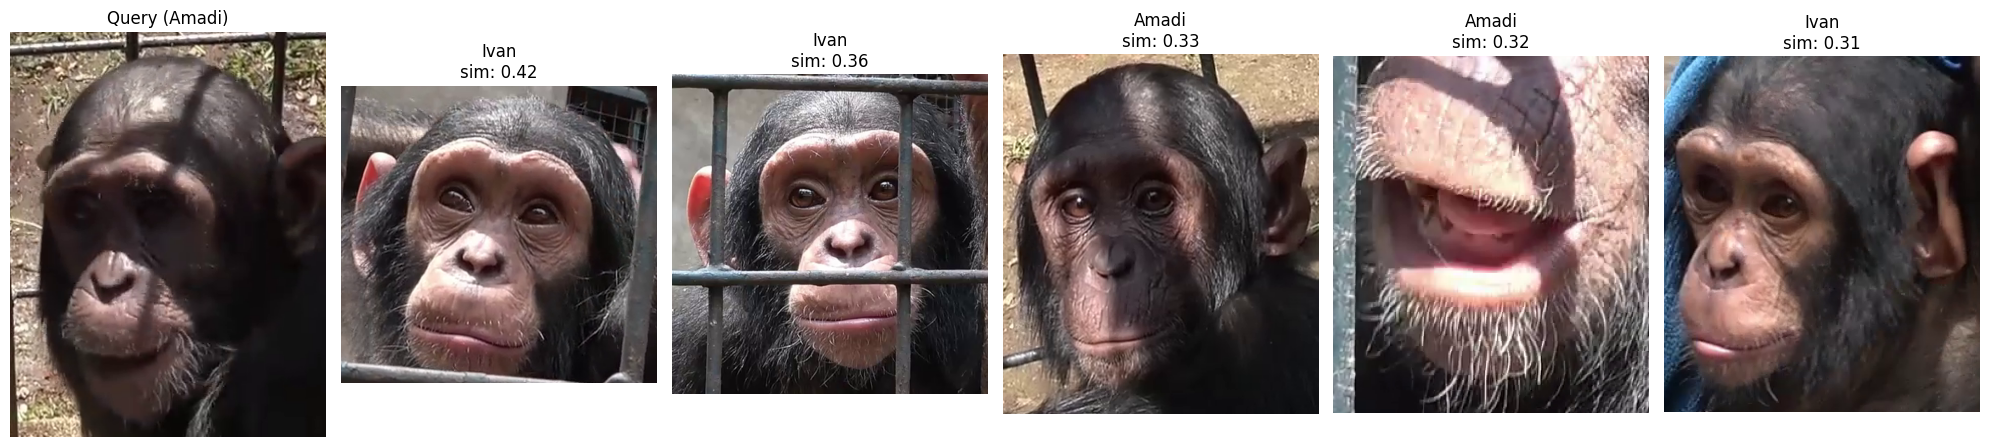

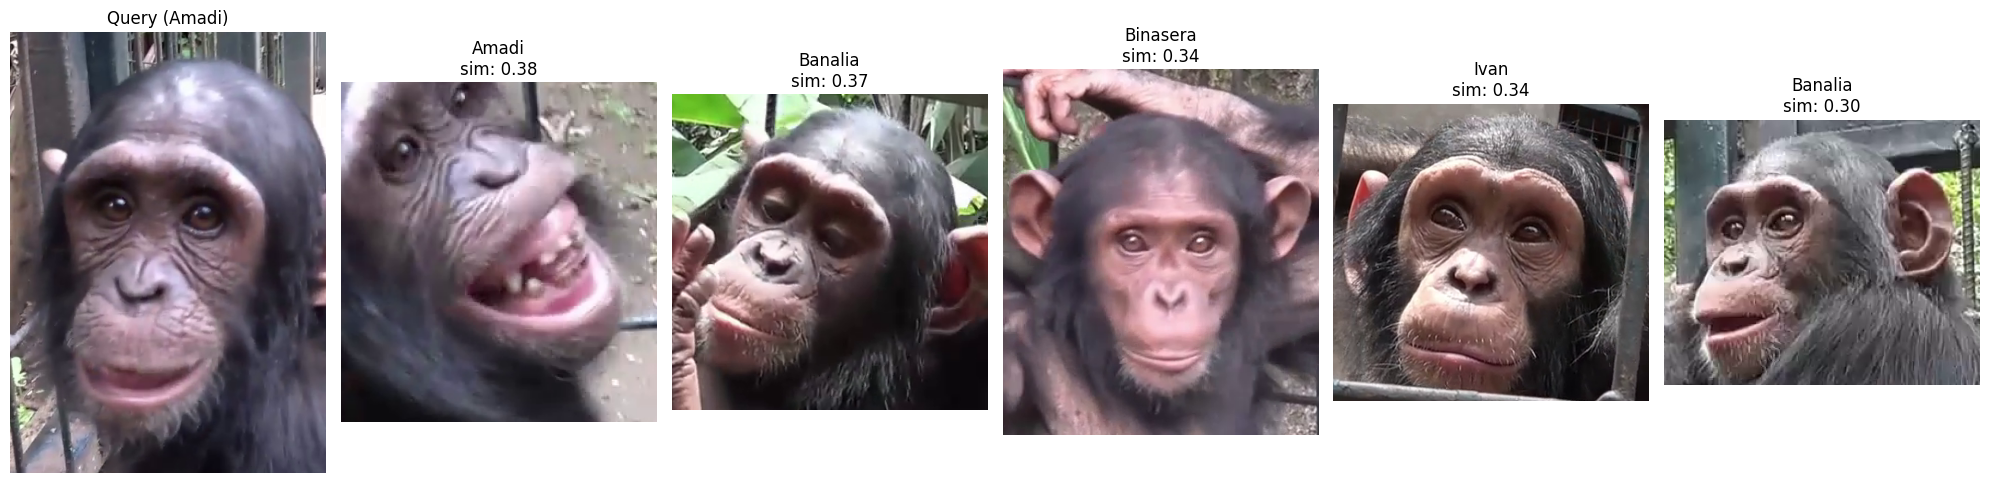

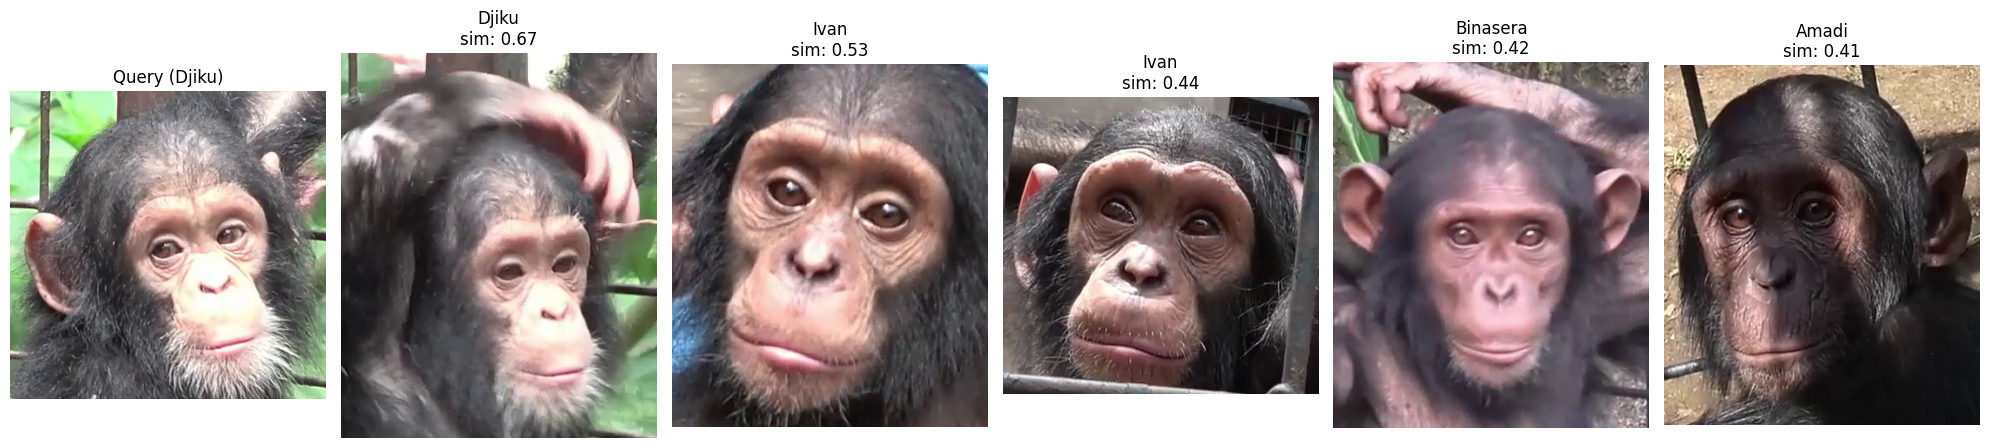

In [6]:
# --- Cell 6: Function to Search (find Top-K matches for a given crop) ---

from sklearn.metrics.pairwise import cosine_similarity

def find_top_matches(query_crop, face_db, top_k=10):
    query_emb = get_embedding(chimpufe_model, query_crop, device)
    embs = np.stack([entry['embedding'] for entry in face_db])
    sims = cosine_similarity([query_emb], embs)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(face_db[i]['chimp_id'], face_db[i]['crop_path'], sims[i]) for i in top_idx]

# --- Cell 6: Interactive Query (choose chimpanzee and image) ---

from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display
import ipywidgets as widgets

# List all chimpanzee names (sorted, as in ChimpPic)
chimp_names = sorted(set(entry['chimp_id'] for entry in face_db))

# Dropdown for chimpanzee
chimp_dropdown = widgets.Dropdown(
    options=chimp_names,
    description="Chimpanzee:",
    value=chimp_names[0]
)

# Function to update image names for a selected chimpanzee
def get_crop_choices(chimp_id):
    # Crop pictures are sorted lexically by crop_path
    crops = sorted(
        [entry for entry in face_db if entry['chimp_id'] == chimp_id],
        key=lambda x: x['crop_path']
    )
    if not crops:
        return ['No images found'], []
    crop_labels = [os.path.basename(entry['crop_path']) for entry in crops]
    return crop_labels, crops

# Update dropdown for image selection
def update_image_dropdown(*args):
    query_chimp = chimp_dropdown.value
    crop_labels, crops = get_crop_choices(query_chimp)
    image_dropdown.options = crop_labels
    image_dropdown.value = crop_labels[0] if crop_labels else ''
    # Save crops list for downstream picking
    image_dropdown.crops = crops

# Dummy initial, will be overwritten
image_dropdown = widgets.Dropdown(options=[''], description="Crop Image:")
chimp_dropdown.observe(update_image_dropdown, names='value')

# Initialize image dropdown
update_image_dropdown()

display(chimp_dropdown, image_dropdown)

# Button to trigger the search
search_button = widgets.Button(description='Find Top Matches')

def on_search_button_clicked(b):
    chimp = chimp_dropdown.value
    crop_label = image_dropdown.value
    crops = image_dropdown.crops
    # Find the selected entry
    for entry in crops:
        if os.path.basename(entry['crop_path']) == crop_label:
            query_entry = entry
            break
    else:
        print("Image not found.")
        return
    query_img = Image.open(query_entry['crop_path'])
    top_matches = find_top_matches(query_img, face_db, top_k=15)  # fetch more to be sure

    # Print header
    print(f"Query: {query_entry['crop_path']} | id: {query_entry['chimp_id']}")
    print("\nTop 10 results (excluding self-match):")
    count = 0
    displayable_matches = []
    for i, (chimpid, path, sim) in enumerate(top_matches):
        # Skip the query image itself (cosine=1.0 or same path)
        if path == query_entry['crop_path'] or abs(sim - 1.0) < 1e-5:
            continue
        count += 1
        print(f"{count:2d}. {chimpid:12s}  {os.path.basename(path):35s}  sim: {sim:.4f}")
        displayable_matches.append((chimpid, path, sim))
        if count >= 10:
            break

    # Visualization of top-5 (excluding the query itself)
    show_results = displayable_matches[:5]
    fig, axes = plt.subplots(1, 1 + len(show_results), figsize=(20, 5))
    axes[0].imshow(query_img)
    axes[0].set_title(f"Query ({query_entry['chimp_id']})")
    axes[0].axis('off')

    for i, (chimpid, path, sim) in enumerate(show_results):
        img = Image.open(path)
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"{chimpid}\nsim: {sim:.2f}")
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()
search_button.on_click(on_search_button_clicked)
display(search_button)

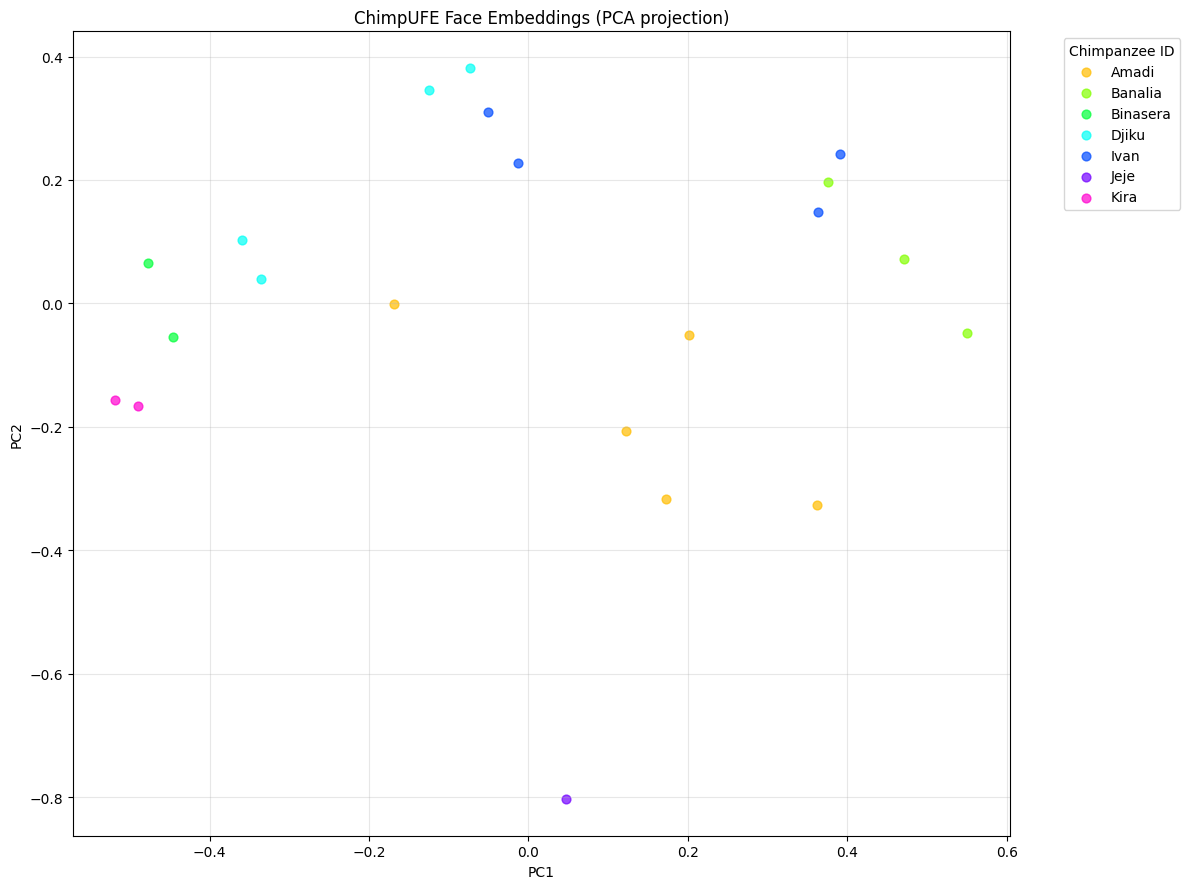

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# Collect embeddings and labels
all_embs = np.stack([entry["embedding"] for entry in face_db])
all_labels = [entry["chimp_id"] for entry in face_db]

# Encode chimpanzee names as integers for coloring
le = LabelEncoder()
labels_encoded = le.fit_transform(all_labels)
unique_chimps = le.classes_

# Run PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(all_embs)

plt.figure(figsize=(12, 9))

# Plot, color by chimpanzee
palette = sns.color_palette("hsv", len(unique_chimps))
for i, chimp in enumerate(unique_chimps):
    idx = [j for j, l in enumerate(all_labels) if l == chimp]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=chimp, alpha=0.7, s=40, color=palette[i])

plt.legend(title="Chimpanzee ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("ChimpUFE Face Embeddings (PCA projection)")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(all_embs)

plt.figure(figsize=(12, 9))
for i, chimp in enumerate(unique_chimps):
    idx = [j for j, l in enumerate(all_labels) if l == chimp]
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=chimp, alpha=0.7, s=40, color=palette[i])

plt.legend(title="Chimpanzee ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("ChimpUFE Face Embeddings (t-SNE projection)")
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: perplexity must be less than n_samples